<b>¡Hola Georgina!</b>

Mi nombre es Alejandro Abia y tengo el gusto de revisar tu proyecto.

A continuación, encontrarás mis comentarios en celdas pintadas de tres colores (verde, amarillo y rojo), a manera de semáforo. Por favor, <b>no las borres ni muevas de posición</b> mientras dure el proceso de revisión.

<div class="alert alert-block alert-success">
<b>Éxito</b> <a class="tocSkip"></a>
En celdas verdes encontrarás comentarios en relación a tus aciertos y fortalezas.
</div>
<div class="alert alert-block alert-warning">
<b>Atención</b> <a class="tocSkip"></a>
Utilizaré el color amarillo para llamar tu atención, expresar algo importante o compartirte alguna idea de valor.
</div>
<div class="alert alert-block alert-danger">
<b>A resolver</b> <a class="tocSkip"></a>
En rojo emitiré aquellos puntos que podrían impedir que el proyecto se ejecute correctamente. No son errores, sino oportunidades importantes de mejora.
</div>
<div class="alert alert-block alert-info">
<b>Comentario estudiante</b> <a class="tocSkip"></a>
Si durante la revisión deseas dejarme algún comentario, por favor utiliza celdas azules como esta.
</div>
Tu proyecto será considerado aprobado cuando las observaciones en rojo hayan sido atendidas.  
¡Empecemos!


# PROYECTO SPRINT 10

## Objetivos del proyecto

+ Priorizar hipótesis que puedan ayudar a aumentar los ingresos de la tienda online.
+ Lanzar un test A/B
+ Analizar los resultados y tomar una decisión entre las 3 posibles:
    1. Parar la prueba, considerar a uno de los grupos como líder.
    2. Parar la prueba, concluir que no hay diferencia entre los grupos.
    3. Continuar la prueba.

## Análisis exploratorio

### Acceder a los datos y prepararlos para el análisis

In [1]:
#Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [2]:
#Acceder a archivos csv
hypothesis= pd.read_csv("/datasets/hypotheses_us.csv", sep= ";")
orders = pd.read_csv("/datasets/orders_us.csv")
visits= pd.read_csv("/datasets/visits_us.csv")

In [3]:
hypothesis

,Hypothesis,Reach,Impact,Confidence,Effort
0,Add two new channels for attracting traffic. T...,3,10,8,6
1,Launch your own delivery service. This will sh...,2,5,4,10
2,Add product recommendation blocks to the store...,8,3,7,3
3,Change the category structure. This will incre...,8,3,3,8
4,Change the background color on the main page. ...,3,1,1,1
5,Add a customer review page. This will increase...,3,2,2,3
6,Show banners with current offers and sales on ...,5,3,8,3
7,Add a subscription form to all the main pages....,10,7,8,5
8,Launch a promotion that gives users discounts ...,1,9,9,5


<div class="alert alert-block alert-success">
<b>Celda [3]</b> <a class="tocSkip"></a><br>
Has cargado correctamente el dataset de hipótesis y lo has explorado para entender su estructura. Este es un paso inicial crucial en el análisis de datos, ya que te permite familiarizarte con la información que vas a trabajar y detectar posibles áreas que requieran limpieza o transformación.
</div>


In [4]:
#Cambiar nombres de columnas para mayor claridad
hypothesis.columns=["hypothesis","reach","impact","confidence","effort"]

In [5]:
hypothesis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   hypothesis  9 non-null      object
 1   reach       9 non-null      int64 
 2   impact      9 non-null      int64 
 3   confidence  9 non-null      int64 
 4   effort      9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes


<div class="alert alert-block alert-warning">
<b>Celda [5]</b> <a class="tocSkip"></a><br>
Aunque has cambiado los nombres de las columnas para mayor claridad, sería beneficioso incluir comentarios en el código que expliquen el propósito de estas modificaciones. Esto no solo ayuda a otros a entender tu proceso de limpieza, sino que también refuerza tu comprensión sobre cómo estas modificaciones impactan en el análisis posterior.
</div>


In [6]:
orders.head()

,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,30.4,B
1,2804400009,3642806036,2019-08-15,15.2,B
2,2961555356,4069496402,2019-08-15,10.2,A
3,3797467345,1196621759,2019-08-15,155.1,B
4,2282983706,2322279887,2019-08-15,40.5,B


In [7]:
#Cambiar nombres de columnas para mayor claridad
orders.columns= ["transaction_id", "visitor_id", "date", "revenue", "group"]

In [8]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  1197 non-null   int64  
 1   visitor_id      1197 non-null   int64  
 2   date            1197 non-null   object 
 3   revenue         1197 non-null   float64
 4   group           1197 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 46.9+ KB


<div class="alert alert-block alert-success">
<b>Celda [8]</b> <a class="tocSkip"></a><br>
La verificación de tipos de datos y la ausencia de valores nulos en el dataset de órdenes es un paso esencial para asegurar la calidad de los datos. Esto garantiza que los análisis posteriores se realicen sobre una base sólida y confiable, minimizando el riesgo de errores debido a datos incorrectos o incompletos.
</div>


In [9]:
visits.head()

,date,group,visits
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


In [10]:
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    62 non-null     object
 1   group   62 non-null     object
 2   visits  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB


No se encontraron valores nulos en ninguno de los 3 datasets

In [11]:
#Cambiar fecha de tipo object a datetime en dataset orders y visits
orders["date"]= pd.to_datetime(orders["date"])
visits["date"]= pd.to_datetime(visits["date"])

<div class="alert alert-block alert-warning">
<b>Celda [11]</b> <a class="tocSkip"></a><br>
Has convertido correctamente las fechas a un formato datetime. Es importante verificar que todas las fechas estén dentro del rango esperado para evitar errores en el análisis temporal. Esto asegura que cualquier análisis basado en el tiempo, como tendencias o estacionalidades, sea preciso y relevante.
</div>


### Detectar filas totalmente duplicadas

In [12]:
print("Filas totalmente duplicadas en hypothesis:", hypothesis.duplicated().sum())
print("Filas totalmente duplicadas en orders:", orders.duplicated().sum())
print("Filas totalmente duplicadas en visits:", visits.duplicated().sum())

Filas totalmente duplicadas en hypothesis: 0
Filas totalmente duplicadas en orders: 0
Filas totalmente duplicadas en visits: 0


<div class="alert alert-block alert-success">
<b>Celda [12]</b> <a class="tocSkip"></a><br>
Es excelente que hayas comprobado la existencia de filas duplicadas en tus datasets. Esto es crucial para evitar que los análisis posteriores se vean afectados por datos redundantes, lo que podría distorsionar los resultados y llevar a conclusiones incorrectas.
</div>


No se encontraron filas totalmente duplicadas en ninguno de los 3 datasets.

### Identificar usuarios duplicados en el dataset orders

In [13]:
ordersA= orders[orders["group"]== "A"]
ordersB= orders[orders["group"]== "B"]

users_A = set(ordersA['visitor_id'])
users_B = set(ordersB['visitor_id'])
duplicated_users = users_A.intersection(users_B)

print(f"Usuarios duplicados: {len(duplicated_users)}")

Usuarios duplicados: 58


Se encontraron 58 usuarios duplicados en el dataset orders.

Los usuarios duplicados en un A/B test son un problema porque rompen la independencia entre grupos: el mismo visitante puede influir en los dos lados, contaminando la comparación. Por tal motivo se procederá a eliminarlos de ambos datasets.

### Eliminar usuarios duplicados

In [14]:
# Filtrar dataset eliminando a los duplicados
orders2 = orders[~orders['visitor_id'].isin(duplicated_users)]

print(f"Usuarios antes de limpiar: {orders['visitor_id'].nunique()}")
print(f"Usuarios después de limpiar: {orders2['visitor_id'].nunique()}")
print(f"Pedidos después de limpiar: {len(orders2)}")

Usuarios antes de limpiar: 1031
Usuarios después de limpiar: 973
Pedidos después de limpiar: 1016


<div class="alert alert-block alert-warning">
<b>Celda [14]</b> <a class="tocSkip"></a><br>
Has identificado y eliminado correctamente a los usuarios duplicados entre los grupos A y B. Documentar este proceso con comentarios es importante para aclarar por qué es crucial en el contexto de un experimento A/B, ya que la presencia de usuarios en ambos grupos puede sesgar los resultados y afectar la validez del experimento.
</div>


## Parte 1: Priorizar hipótesis

In [15]:
#Aplicar el framework ICE para priorizar hipótesis. 
hypothesis["ice"] = hypothesis["impact"]*hypothesis["confidence"]/hypothesis["effort"]

#Ordenarlas en orden descendente de prioridad.
hypothesis[["hypothesis", "ice"]].sort_values(by= "ice", ascending= False)

,hypothesis,ice
8,Launch a promotion that gives users discounts ...,16.200000
0,Add two new channels for attracting traffic. T...,13.333333
7,Add a subscription form to all the main pages....,11.200000
6,Show banners with current offers and sales on ...,8.000000
2,Add product recommendation blocks to the store...,7.000000
1,Launch your own delivery service. This will sh...,2.000000
5,Add a customer review page. This will increase...,1.333333
3,Change the category structure. This will incre...,1.125000
4,Change the background color on the main page. ...,1.000000


<div class="alert alert-block alert-success">
<b>Celda [15]</b> <a class="tocSkip"></a><br>
La aplicación del framework ICE para priorizar hipótesis es una práctica efectiva para enfocar los esfuerzos en las ideas más prometedoras. Has implementado correctamente el cálculo y ordenamiento, lo cual es fundamental para gestionar los recursos de manera eficiente y maximizar el impacto de las iniciativas.
</div>


In [16]:
#Aplicar el framework RICE para priorizar hipótesis. 
hypothesis["rice"]= (hypothesis["reach"]*hypothesis["impact"]*hypothesis["confidence"])/hypothesis["effort"]

#Ordenarlas en orden descendente de prioridad.
hypothesis[["hypothesis", "rice"]].sort_values(by= "rice", ascending= False)

,hypothesis,rice
7,Add a subscription form to all the main pages....,112.0
2,Add product recommendation blocks to the store...,56.0
0,Add two new channels for attracting traffic. T...,40.0
6,Show banners with current offers and sales on ...,40.0
8,Launch a promotion that gives users discounts ...,16.2
3,Change the category structure. This will incre...,9.0
1,Launch your own delivery service. This will sh...,4.0
5,Add a customer review page. This will increase...,4.0
4,Change the background color on the main page. ...,3.0


<div class="alert alert-block alert-warning">
<b>Celda [16]</b> <a class="tocSkip"></a><br>
Al aplicar el framework RICE, sería útil explicar la diferencia entre ICE y RICE, y por qué ambos son relevantes para la priorización de hipótesis. Esto enriquecerá la comprensión del lector sobre la metodología utilizada, destacando cómo el factor 'Reach' en RICE puede cambiar la priorización de las hipótesis en comparación con ICE.
</div>


**Cómo cambia la priorización de hipótesis cuando utilizas RICE en lugar de ICE:**

+ Utilizando el método ICE podemos observar que la hipótesis que ocupa el primer lugar en prioridad es la #8 (puntaje ice de 16.2), a comparación del método RICE, donde la hipótesis #7 ocupa el primer lugar (puntaje rice de 112.0).

+ Dentro del top 5 de hipótesis con mayor prioridad, para ambos métodos, se encuentran las hipótesis con número 8,0,7,6 y 2.

+ Es importante mencionar que el método ICE no toma en cuenta el parámetro "Reach", a comparación del RICE donde sí tiene valor. Este parámetro es importante para saber a cuántas personas afectará ese cambio y maximizar el impacto total del negocio.

+ Tomando en cuenta el método RICE, podemos observar que la hipótesis #7 tiene mayor alcance (10), un impacto medio alto (7), confianza alta (8), y esfuerzo medio (5). Esto le da ventaja sobre las demás y podría considerarse como la hipótesis con la prioridad 1.

+ En segundo lugar podríamos considerar a la hipótesis #2 ya que tiene un alcance alto (8), un impacto bajo (3), pero una confianza media alta (7) y un esfuerzo bajo (3).

+ Y en tercer lugar se podría considerar la hipótesis #0 ya que tiene un alcance bajo (3), pero un impacto muy alto (10), una confianza alta (8), y un esfuerzo medio (6).


## Parte 2: Análisis del test A/B

### 1. Representar gráficamente el ingreso acumulado por grupo

In [17]:
#Crear una matriz con valores únicos de parejas fecha-grupo
dates_groups= orders2[["date", "group"]].drop_duplicates()

#Recopilar los datos diarios acumulados agregados sobre los pedidos
orders_aggregated = dates_groups.apply (
    lambda x: orders2[np.logical_and(
            orders2['date'] <= x['date'], orders2['group'] == x['group']
        )
    ].agg({ 'date': 'max',
            'group': 'max',
            'transaction_id': pd.Series.nunique,
            'visitor_id': pd.Series.nunique,
            'revenue': 'sum'}), axis=1).sort_values(by=['date', 'group'])

orders_aggregated.head()

,date,group,transaction_id,visitor_id,revenue
55,2019-08-01,A,23,19,2266.6
66,2019-08-01,B,17,17,967.2
175,2019-08-02,A,42,36,3734.9
173,2019-08-02,B,40,39,3535.3
291,2019-08-03,A,66,60,5550.1


In [18]:
#Obtener los datos diarios acumulados agregados sobre los visitantes

visitors_aggregated = dates_groups.apply(
    lambda x: visits[
        np.logical_and(
            visits['date'] <= x['date'], visits['group'] == x['group']
        )
    ].agg({'date': 'max', 
           'group': 'max', 
           'visits': 'sum'}), axis=1).sort_values(by=['date', 'group'])

visitors_aggregated.head()

,date,group,visits
55,2019-08-01,A,719
66,2019-08-01,B,713
175,2019-08-02,A,1338
173,2019-08-02,B,1294
291,2019-08-03,A,1845


In [19]:
#Fusionar las dos tablas y renombrar columnas
cumulative_data = orders_aggregated.merge(visitors_aggregated, left_on=['date', 'group'], 
                                          right_on=['date', 'group'])

cumulative_data.columns = ['date', 'group', 'orders', 'buyers', 'revenue', 'visitors']

cumulative_data.head()

,date,group,orders,buyers,revenue,visitors
0,2019-08-01,A,23,19,2266.6,719
1,2019-08-01,B,17,17,967.2,713
2,2019-08-02,A,42,36,3734.9,1338
3,2019-08-02,B,40,39,3535.3,1294
4,2019-08-03,A,66,60,5550.1,1845


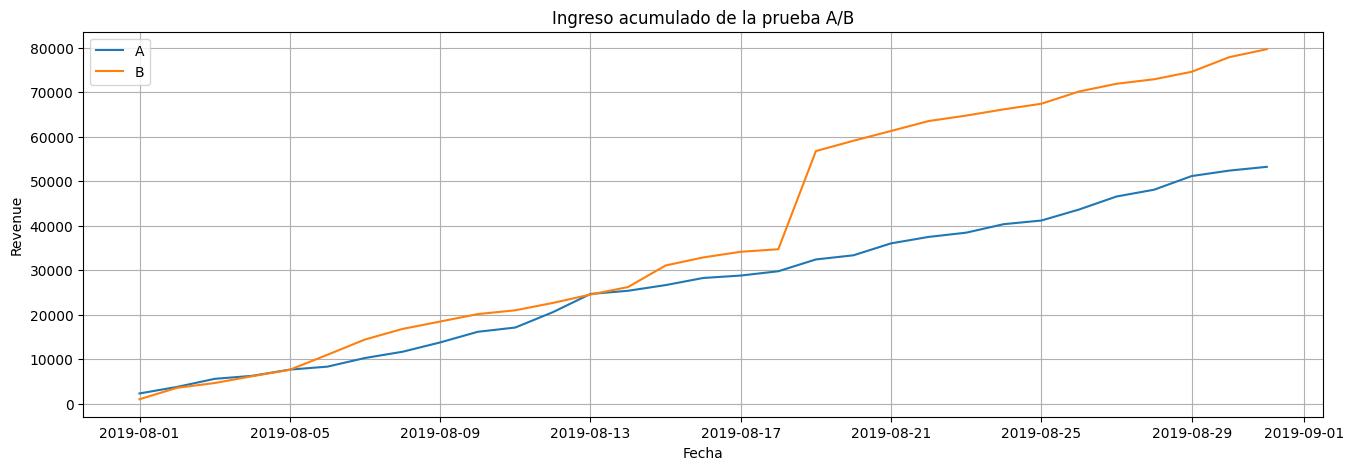

In [20]:
#Gráficos de ingresos acumulados por día y grupo de prueba A/B

# DataFrame con pedidos acumulados e ingresos acumulados por día, grupo A
cumulative_revenueA = cumulative_data[cumulative_data['group']=='A'][['date','revenue', 'orders']]

# DataFrame con pedidos acumulados e ingresos acumulados por día, grupo B
cumulative_revenueB = cumulative_data[cumulative_data['group']=='B'][['date','revenue', 'orders']]

# Trazar el gráfico de ingresos del grupo A
plt.figure(figsize= (16,5))
plt.title("Ingreso acumulado de la prueba A/B")
plt.plot(cumulative_revenueA['date'], cumulative_revenueA['revenue'], label='A')

# Trazar el gráfico de ingresos del grupo B
plt.plot(cumulative_revenueB['date'], cumulative_revenueB['revenue'], label='B')

plt.xlabel("Fecha")
plt.ylabel("Revenue")
plt.legend()
plt.grid()
plt.show()

<div class="alert alert-block alert-success">
<b>Celda [20]</b> <a class="tocSkip"></a><br>
Has visualizado de manera efectiva los ingresos acumulados por día y grupo de prueba A/B. Este tipo de visualización es crucial para identificar tendencias y diferencias entre los grupos a lo largo del tiempo, permitiéndote observar cómo evoluciona el rendimiento de cada grupo y detectar patrones significativos.
</div>


De acuerdo al gráfico anterior se observa que:
+ Los ingresos en ambos grupos aumentan constantemente durante toda la prueba.
+ Los ingresos del grupo B tienen un pico en el día 19-08-2019, pasando de un revenue de 42,481.7 (el día anterior) a 64,546.6
+ El grupo A alcanzó un revenue de 64,554.9 al final de la prueba, mientras que el grupo B alcanzó uno de 92,840.6 

### 2. Representa gráficamente el tamaño de pedido promedio acumulado por grupo. 

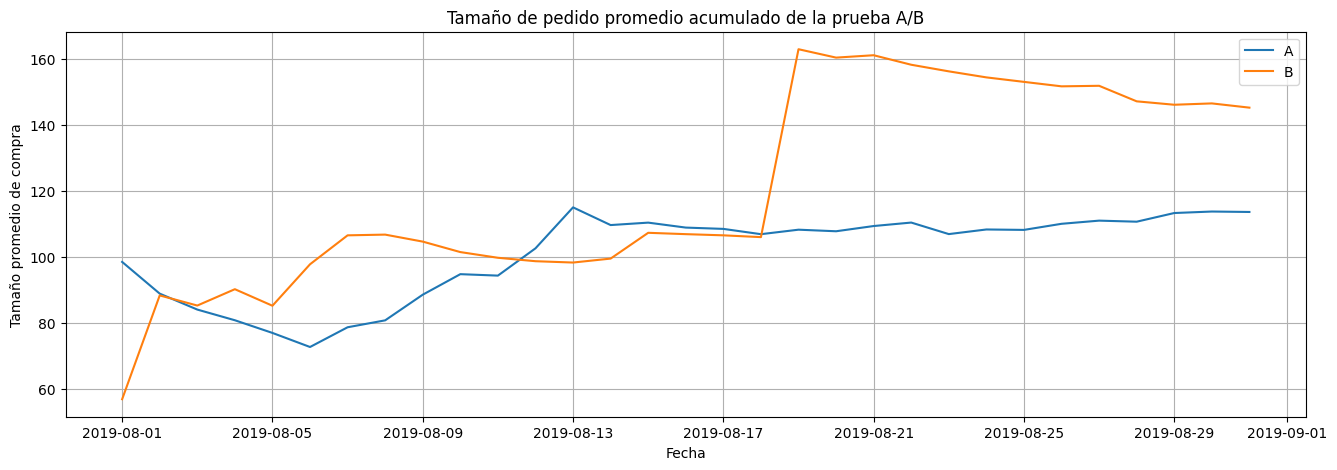

In [21]:
#Gráfico del tamaño de pedido promedio acumulado 
plt.figure(figsize= (16,5))
plt.title("Tamaño de pedido promedio acumulado de la prueba A/B")

size_orderA= cumulative_revenueA['revenue']/cumulative_revenueA['orders']
size_orderB= cumulative_revenueB['revenue']/cumulative_revenueB['orders']

plt.plot(cumulative_revenueA['date'], size_orderA, label='A')
plt.plot(cumulative_revenueB['date'], size_orderB , label='B')

plt.xlabel("Fecha")
plt.ylabel("Tamaño promedio de compra")
plt.legend()
plt.grid()
plt.show()

De acuerdo al gráfico anterior se puede observar que:
+ El grupo A tuvo un descenso en el tamaño de pedido acumulado durante los primeros 7 días de la prueba y después se recuperó, alcanzando un pico de 118.22 el día 13-08-2019. Posteriormente se mantuvo estable hasta el final de la prueba, con valores por debajo de los 120.

+ El grupo B por su parte presentó mayores fluctuaciones. Al princio de la prueba presentó un pico ascendente a partir del séptimo día y posteriormente se mantuvo constante hasta el día 19-08-2019 en donde alcanzó un valor máximo de 160.16. Después presentó un ligero descenso que se mantuvo constante hasta el final de la prueba, con valores por encima de 140.

### 3. Representa gráficamente la diferencia relativa en el tamaño de pedido promedio acumulado para el grupo B en comparación con el grupo A

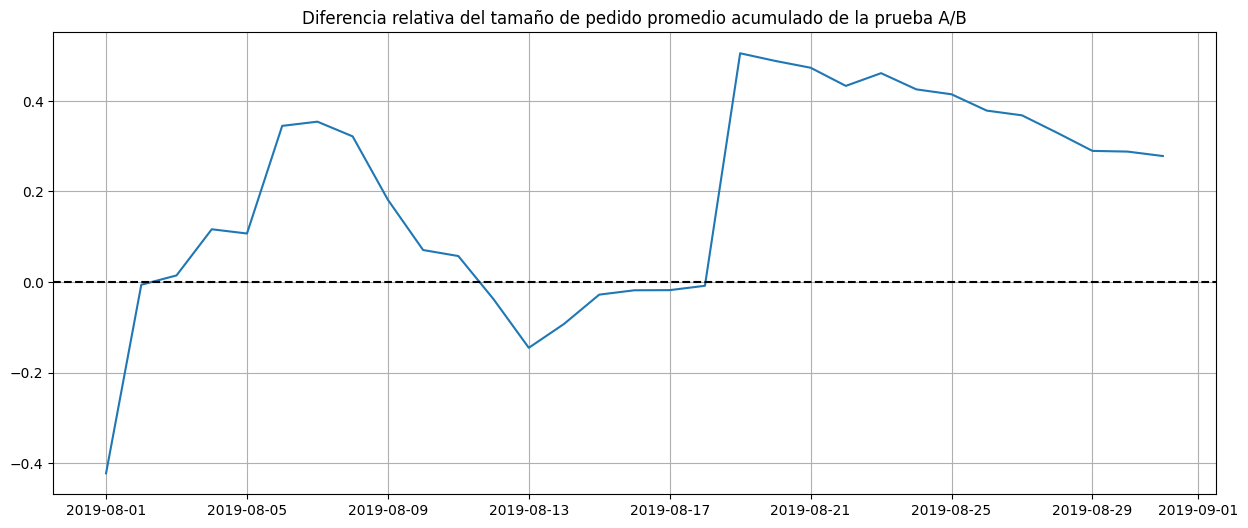

In [22]:
#Reunir los datos en un DataFrame
merged_cum_rev = cumulative_revenueA.merge(cumulative_revenueB, 
                                           left_on='date', 
                                           right_on='date', 
                                           how='left', suffixes=['A', 'B'])

merged_cum_revA= merged_cum_rev['revenueA']/merged_cum_rev['ordersA']
merged_cum_revB= merged_cum_rev['revenueB']/merged_cum_rev['ordersB']

#Trazar un gráfico de diferencia relativa para los tamaños de compra promedio
plt.figure(figsize= (15,6))
plt.title("Diferencia relativa del tamaño de pedido promedio acumulado de la prueba A/B")
plt.plot(merged_cum_rev['date'],(merged_cum_revB /merged_cum_revA)-1)

# agregar el eje X
plt.axhline(y=0, color='black', linestyle='--')
plt.grid()
plt.show()

De acuerdo al gráfico anterior se observa que:
+ En algunos días se observan cambios muy marcados entre ambos grupos. Al inicio de la prueba se observa un ascenso, lo cual indica que el grupo B es consitentemente mejor que A (diferencia relativa de +3%)

+ A partir del día 08-09-2019 se empieza a ver un descenso hasta llegar a valores por debajo de 0 hacia el día 13-08-2019. Esto nos indica que en este período el grupo B presentó un efecto negativo (diferencia de -1%).
  
+ Durante el día 18-08-2019 se observa nuevamente un pico ascendente, alcanzando una diferencia de casi 5%

+ Después los valores se estabilizan hacia el final de la prueba.

+ Estos cambios tan marcados se podrían deber a valores atípicos en el tamaño de compra.

### 4. Calcula la tasa de conversión de cada grupo como la relación entre los pedidos y el número de visitas de cada día.

In [23]:
#Calcular tasa de conversión (orders/visitors)
cumulative_data["conversion"] = cumulative_data["orders"]/cumulative_data["visitors"]
cumulative_data["pct_conversion"]= cumulative_data["conversion"]*100

In [24]:
cumulative_data.head()

,date,group,orders,buyers,revenue,visitors,conversion,pct_conversion
0,2019-08-01,A,23,19,2266.6,719,0.031989,3.198887
1,2019-08-01,B,17,17,967.2,713,0.023843,2.384292
2,2019-08-02,A,42,36,3734.9,1338,0.031390,3.139013
3,2019-08-02,B,40,39,3535.3,1294,0.030912,3.091190
4,2019-08-03,A,66,60,5550.1,1845,0.035772,3.577236


In [25]:
#Filtrar datos por grupos
cumulative_dataA= cumulative_data[cumulative_data["group"]== "A"]
cumulative_dataB= cumulative_data[cumulative_data["group"]== "B"]

print("Datos acumulados grupo A")
display(cumulative_dataA.head())
print("Datos acumulados grupo B")
display(cumulative_dataB.head())

Datos acumulados grupo A


,date,group,orders,buyers,revenue,visitors,conversion,pct_conversion
0,2019-08-01,A,23,19,2266.6,719,0.031989,3.198887
2,2019-08-02,A,42,36,3734.9,1338,0.031390,3.139013
4,2019-08-03,A,66,60,5550.1,1845,0.035772,3.577236
6,2019-08-04,A,77,71,6225.6,2562,0.030055,3.005464
8,2019-08-05,A,99,92,7623.6,3318,0.029837,2.983725


Datos acumulados grupo B


,date,group,orders,buyers,revenue,visitors,conversion,pct_conversion
1,2019-08-01,B,17,17,967.2,713,0.023843,2.384292
3,2019-08-02,B,40,39,3535.3,1294,0.030912,3.091190
5,2019-08-03,B,54,53,4606.9,1803,0.029950,2.995008
7,2019-08-04,B,68,66,6138.5,2573,0.026428,2.642829
9,2019-08-05,B,89,87,7587.8,3280,0.027134,2.713415


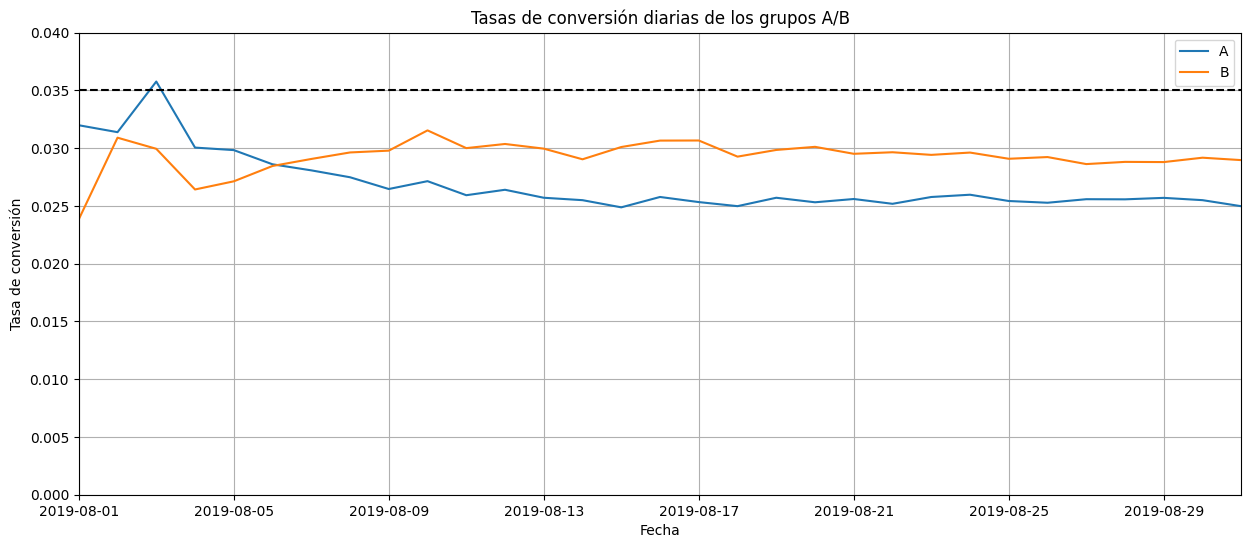

In [26]:
#Trazar gráfico de las tasas de conversión diarias de los grupos A/B
start_date = pd.to_datetime('2019-08-01')
end_date= pd.to_datetime('2019-08-31')

xA= cumulative_dataA['date']
yA= cumulative_dataA['conversion']

xB= cumulative_dataB['date']
yB= cumulative_dataB['conversion']

plt.figure(figsize= (15,6))
plt.plot(xA, yA, label= 'A')
plt.plot(xB, yB, label= 'B')
plt.title("Tasas de conversión diarias de los grupos A/B")
plt.xlabel("Fecha")
plt.ylabel("Tasa de conversión")
plt.legend()
plt.grid()
plt.axis([start_date, end_date, 0,0.04])
plt.axhline(y=0.035, color='black', linestyle='--')
plt.show()

<div class="alert alert-block alert-warning">
<b>Celda [26]</b> <a class="tocSkip"></a><br>
El gráfico de tasas de conversión diarias es informativo. Agregar anotaciones o líneas de referencia podría resaltar momentos clave o cambios significativos en las tasas de conversión, proporcionando un contexto adicional que ayude a interpretar mejor los resultados y a identificar eventos que puedan haber influido en las conversiones.
</div>


De acuerdo al gráfico anterior se observa que:
+ Al inicio de la prueba el grupo A presentaba una tasa de conversión mayor que el grupo B, llegando a un pico máximo de de 3.5%. Sin embargo, conforme avanzó la prueba la tasa de conversión disminuyó a un valor de 2.5% que se mantuvo estable hasta el final de la prueba.

+ En el caso del grupo B, al incio de la prueba su tasa de conversión era menor que el grupo A, pero en el transcurso de la prueba alcanzó un valor del 3% que se mantuvo constante hasta el final de la prueba.

+ Ambos grupos estabilizaron su tasa de conversión a partir del día 13-08-2019 hasta el final de la prueba. Esto, nos deja ver con claridad que el grupo B presentó mayor conversión que el grupo A.

In [27]:
#Calcular la diferencia en la tasa de conversión entre ambos grupos 
merged_cum_conversions= cumulative_dataA[['date','conversion']].merge(cumulative_dataB[['date','conversion']], 
           left_on= 'date', right_on= 'date', how= 'left', suffixes=['A', 'B'])

merged_cum_conversions.head()

,date,conversionA,conversionB
0,2019-08-01,0.031989,0.023843
1,2019-08-02,0.031390,0.030912
2,2019-08-03,0.035772,0.029950
3,2019-08-04,0.030055,0.026428
4,2019-08-05,0.029837,0.027134


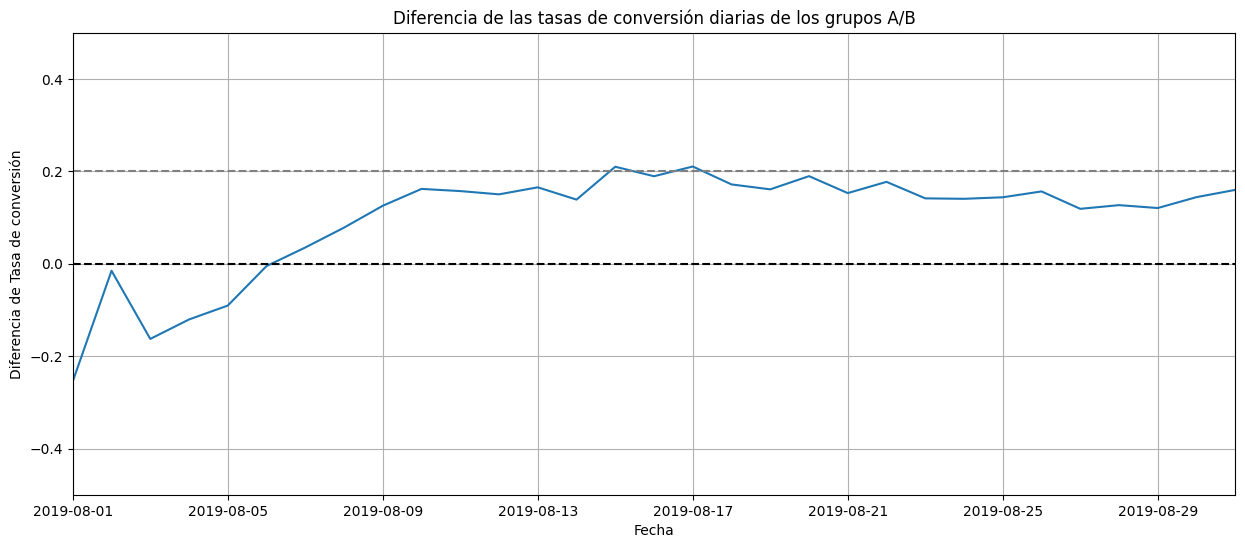

In [28]:
#Graficar la diferencia de la tasa de conversión entre ambos grupos
plt.figure(figsize= (15,6))
plt.plot(merged_cum_conversions['date'], 
         merged_cum_conversions['conversionB']/merged_cum_conversions['conversionA']-1)

plt.title("Diferencia de las tasas de conversión diarias de los grupos A/B")
plt.xlabel("Fecha")
plt.ylabel("Diferencia de Tasa de conversión")
plt.axhline(y=0, color='black', linestyle='--')
plt.axhline(y=0.2, color='grey', linestyle='--')
plt.axis([pd.to_datetime("2019-08-01"), pd.to_datetime('2019-08-31'), -0.5, 0.5])
plt.grid()
plt.show()

El gráfico anterior nos permite observar claramente la diferencia en las tasas de conversión entre ambos grupos. En este caso, se observa una diferencia de 20% a favor del grupo B. Esta diferencia se mantiene estable hasta el final de la prueba.

### 5. Traza un gráfico de dispersión del número de pedidos por usuario

In [29]:
#Extraer el número de órdenes únicas por usuario 
orders_by_users= orders2.groupby('visitor_id', as_index= False).agg({'transaction_id': pd.Series.nunique})
orders_by_users.columns = ['user_id', 'orders']

display(orders_by_users.sort_values('orders', ascending= False).head(10))

,user_id,orders
908,3967698036,3
55,249864742,3
478,2108163459,3
687,2988190573,3
890,3908431265,3
138,611059232,3
632,2742574263,3
157,678354126,2
323,1404560065,2
452,1985475298,2


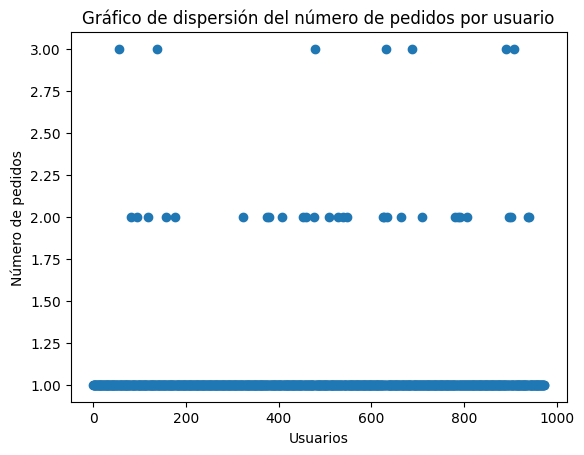

In [30]:
#Grafico de dispersión
x_values = pd.Series(range(0, len(orders_by_users['orders'])))
plt.scatter(x_values, orders_by_users['orders'])
plt.title("Gráfico de dispersión del número de pedidos por usuario")
plt.xlabel("Usuarios")
plt.ylabel("Número de pedidos")
plt.show()

El gráfico anterior nos ayuda a confirmar que la mayoría de los usuarios realiza entre 1 y 2 pedidos. Pero existen casos atípicos donde se realizaron 3 pedidos.

### 6. Calcula los percentiles 95 y 99 del número de pedidos por usuario. Define el punto en el cual un punto de datos se convierte en una anomalía

In [31]:
np.percentile(orders_by_users["orders"], [95,99])

array([1., 2.])

Los percentiles nos muestran que:
+ El 1% de los usuarios realizó más de 2 pedidos, o bien el 99% de los usuarios hizo 2 pedidos o menos.
+ El 5% de los usuarios realizó más de 1 pedido, o bien el 95% de los usuarios hizo 1 pedido o menos.
+ Lo anterior nos ayuda a fijar un límite superior de órdenes para considerar un comportamiento normal del usuario, en este caso el umbral sería 2 órdenes, ya que así se mantiene el 99% de los datos y se elimina el 1% más extremo, conservando suficiente información para el análisis.
+ Datos de órdenes que sean mayores a 2 serán eliminados por considerarse anomalías.

In [32]:
# Identificar usuarios anómalos
anomalous_users = orders_by_users[orders_by_users > 2].index
anomalous_users.nunique()

973

### 7. Traza un gráfico de dispersión de los precios de los pedidos

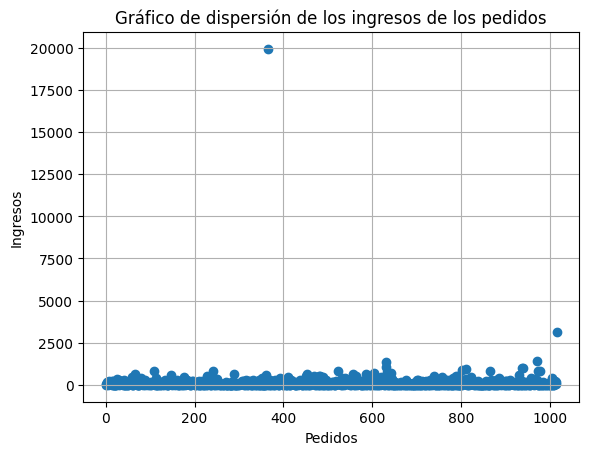

In [33]:
#Definir valores de eje x 
x_values = pd.Series(range(0, len(orders2["revenue"])))

#Gráfico de dispersión
plt.scatter(x_values, orders2["revenue"])
plt.title("Gráfico de dispersión de los ingresos de los pedidos")
plt.xlabel("Pedidos")
plt.ylabel("Ingresos")
plt.grid()
plt.show()

De acuerdo al gráfico anterior se observa que la mayoría de los pedidos corresponden a un ingreso de menos de 1,500. Sin embargo, también se observan casos anormales en donde los ingresos son de más de 2,500 y de hasta 20,000.

### 8. Calcula los percentiles 95 y 99 de los precios de los pedidos. Define el punto en el cual un punto de datos se convierte en una anomalía

In [34]:
np.percentile(orders2["revenue"], [95,99])

array([414.275, 830.3  ])

Los percentiles nos muestran que:

+ El 1% de los usuarios realizó pedidos de más de 830.3, o bien el 99% de los usuarios hizo pedidos que costaron 830.3 o menos.
+ El 5% de los usuarios realizó pedidos de más de 414.275, o bien el 95% de los usuarios hizo pedidos que costaron 414.275 o menos.
+ Lo anterior nos ayuda a fijar un límite superior de ingresos por pedido para considerar un comportamiento normal del usuario, en este caso el umbral sería un precio de 830.5, ya que así se mantiene el 99% de los datos y se elimina el 1% más extremo, conservando suficiente información para el análisis.

### 9. Encuentra la significancia estadística de la diferencia en la conversión entre los grupos utilizando los datos en bruto

In [35]:
orders_by_usersA = orders2[orders2['group']=='A'
    ].groupby('visitor_id', as_index=False).agg({'transaction_id' : pd.Series.nunique})
orders_by_usersA.columns = ['user_id', 'orders']

orders_by_usersB = orders2[orders2['group']=='B'
    ].groupby('visitor_id', as_index=False).agg({'transaction_id' : pd.Series.nunique})
orders_by_usersB.columns = ['user_id', 'orders']

In [36]:
print("Órdenes de grupo A")
display(orders_by_usersA.head())
print("Órdenes de grupo B")
display(orders_by_usersB.head())

Órdenes de grupo A


,user_id,orders
0,11685486,1
1,54447517,1
2,66685450,1
3,78758296,1
4,85103373,1


Órdenes de grupo B


,user_id,orders
0,5114589,1
1,6958315,1
2,39475350,1
3,47206413,1
4,48147722,1


In [37]:
pd.Series(0, index=np.arange(visits[visits['group']=='A']['visits'
    ].sum() - len(orders_by_usersA['orders'])), name='orders')

#Crear muestras A y B
sampleA= pd.concat([orders_by_usersA['orders'],
                    pd.Series(0, index=np.arange(visits[visits['group']=='A']['visits'
                        ].sum() - len(orders_by_usersA['orders'])), name='orders')], axis=0)

sampleB = pd.concat([orders_by_usersB['orders'],
                     pd.Series(0, index=np.arange(visits[visits['group']=='B']['visits'
                         ].sum() - len(orders_by_usersB['orders'])), name='orders')],axis=0)

In [38]:
#Aplicar prueba estadística MannWhitneyU y calcular diferencia en la conversión entre grupos
print("{0:.5f}".format(stats.mannwhitneyu(sampleA, sampleB)[1]))

print("{0:.3f}".format(sampleB.mean()/sampleA.mean()-1))

0.01102
0.160


<div class="alert alert-block alert-success">
<b>Celda [38]</b> <a class="tocSkip"></a><br>
Has aplicado correctamente la prueba estadística de Mann-Whitney U para comparar las conversiones entre los grupos A y B. Este enfoque es adecuado para datos no paramétricos y proporciona una base sólida para tus conclusiones, asegurando que las diferencias observadas no se deban al azar.
</div>


+ El valor p de la prueba es: 0.01102, que es menor que el nivel de significancia 0.05. Esto nos indica que sí existen diferencias significativas en la conversión entre grupos.
+ La diferencia relativa de conversión en promedio es un 16% mayor en el grupo B que en el A.

### 10. Encuentra la significancia estadística de la diferencia en el tamaño promedio de pedido entre los grupos utilizando los datos en bruto

In [39]:
revenueA = orders2[orders2['group']=='A']['revenue']
revenueB = orders2[orders2['group']=='B']['revenue']

print('{0:.3f}'.format(stats.mannwhitneyu(revenueA, revenueB)[1]))
print('{0:.3f}'.format(revenueB.mean()/revenueA.mean()-1))

0.862
0.278


El valor p de 0.862 es superior a 0.05 por lo que no existen diferencias estadísticamente significativas entre los tamaños de pedido promedio de los grupos. Además, la diferencia relativa es solo del 2.7%

### 11. Encuentra la significancia estadística de la diferencia en la conversión entre los grupos utilizando los datos filtrados

En primer lugar se eliminarán los datos que se consideran anómalos:
+ Usuarios que realizaron más de 2 pedidos (percentil 99) y pedidos con revenue mayor a 830.5 (percentil 99). De esta forma se eliminará el 1% de los usuarios con más órdenes y con pedidos muy caros.

In [40]:
atypical_orders = pd.concat([orders_by_usersA[orders_by_usersA['orders'] > 2]['user_id'], 
                                 orders_by_usersB[orders_by_usersB['orders'] > 2]['user_id']], axis = 0)

atypical_revenue = orders2[orders2['revenue'] > 830.5]['visitor_id']

#Extraer datos anómalos 
abnormal_users = pd.concat([atypical_orders, atypical_revenue], axis = 0).drop_duplicates().sort_values()

print("Usuarios anormales:", len(abnormal_users))

Usuarios anormales: 16


In [41]:
#Crear muestras filtradas
sampleA_filtered = pd.concat([orders_by_usersA
    [np.logical_not(orders_by_usersA['user_id'].isin(abnormal_users))]['orders'],
                              pd.Series(0, index=np.arange(visits[visits['group']=='A']['visits'].sum() 
                                                           - len(orders_by_usersA['orders'])),name='orders')],axis=0)

sampleB_filtered = pd.concat([orders_by_usersB
    [np.logical_not(orders_by_usersB['user_id'].isin(abnormal_users))]['orders'],
                              pd.Series(0, index=np.arange(visits[visits['group']=='B']['visits'].sum() 
                                                           - len(orders_by_usersB['orders'])),name='orders')],axis=0)

#Aplicar prueba MannWhitney U y calcular diferencia en la conversión entre grupos
print("{0:.5f}".format(stats.mannwhitneyu(sampleA_filtered, sampleB_filtered)[1]))
print("{0:.3f}".format(sampleB_filtered.mean()/sampleA_filtered.mean()-1))

0.00702
0.189


+ Al comparar las muestras filtradas se obtuvo un valor p de 0.00702 que es menor que el valor de significancia 0.05. Esto nos indica que sí existen diferencias significativas en la conversión entre los grupos filtrados.
  
+ La diferencia relativa de conversión en promedio es un 18.9% mayor en el grupo B que en el A.

### 12. Encuentra la significancia estadística de la diferencia en el tamaño promedio de pedido entre los grupos utilizando los datos filtrados

In [42]:
#Filtrar muestras
revenueA_filtered= orders2[np.logical_and(
        orders2['group']=='A',
        np.logical_not(orders2['visitor_id'].isin(abnormal_users)))]['revenue']

revenueB_filtered= orders2[np.logical_and(
        orders2['group']=='B',
        np.logical_not(orders2['visitor_id'].isin(abnormal_users)))]['revenue']

print("{0:.3f}".format(stats.mannwhitneyu(revenueA_filtered, revenueB_filtered)[1]))
print("{0:.3f}".format(revenueB_filtered.mean() / revenueA_filtered.mean() - 1))

0.822
-0.032


<div class="alert alert-block alert-warning">
<b>Celda [42]</b> <a class="tocSkip"></a><br>
Al filtrar usuarios anómalos y recalcular las métricas, es importante discutir cómo estos valores atípicos podrían haber afectado tus resultados iniciales. Esto ayudará a contextualizar la importancia de este paso en el análisis, mostrando cómo los outliers pueden influir en las conclusiones y por qué es crucial tratarlos adecuadamente.
</div>


+ Al comparar las muestras filtradas, se obtuvo un valor p de 0.822 que es superior al valor de significancia 0.05 por lo tanto, se puede concluir que no existen diferencias estadísticamente significativas entre los tamaños de pedido promedio de los grupos. 

+ Además, la diferencia relativa es negativa, es decir en promedio la muestra B presenta un valor 3.2% más bajo que la muestra A.

### 13. Toma una decisión basada en los resultados de la prueba

De acuerdo a los resultados obtenidos de la prueba estadística Mann Whitney U con las muestras filtradas se puede resumir que:

- El valor-p = 0.00702  es estadísticamente significativo, lo que indica que sí existen diferencias significativas en la tasa de conversión.
- La diferencia en la conversión entre los grupos es 18.9%, un resultado que se considera muy relevante ya que demuestra que la mejora que se puso a prueba tuvo éxito.

Por lo anterior, la decisión más acertada es parar la prueba y declarar al grupo B como ganador, ya que en promedio el grupo B obtuvo un 18.9% más conversión que el grupo A.

## Conclusión final:

+ Tras aplicar los frameworks ICE y RICE, observamos que las prioridades de las hipótesis cambian al considerar el Reach: algunas ideas con alto impacto y confianza bajaron de rango al tener bajo alcance, mientras que otras con mayor cobertura subieron en prioridad. Esto nos permite enfocar los esfuerzos en iniciativas que no solo tienen potencial de impacto, sino también un mayor alcance en usuarios.

En el análisis del test A/B, identificamos diferencias claras:

1. El grupo B mostró una tasa de conversión significativamente mayor que el grupo A, manteniendo un valor promedio de pedido similar tras filtrar anomalías.

2. Las anomalías detectadas (usuarios con muchos pedidos y órdenes con valores atípicos) distorsionaban los resultados, pero al filtrarlas las conclusiones se mantuvieron consistentes.

3. La evidencia estadística respalda que el grupo B es el ganador, ya que mejora la conversión sin comprometer el ingreso promedio por pedido.

**Recomendación final:** detener la prueba y adoptar las estrategias del grupo B como la mejor opción para aumentar ingresos. Además, mantener un sistema de priorización con RICE permitirá que las futuras pruebas se enfoquen en hipótesis de mayor impacto y escalabilidad.

<div class="alert alert-block alert-success">
<b>Comentario final</b> <a class="tocSkip"></a><br>
¡Muy buen trabajo, Georgina! A lo largo del proyecto mostraste fortalezas muy claras:<br><br>
• Carga y exploración inicial de datos bien ejecutada.<br>
• Renombramiento de columnas para mayor claridad.<br>
• Verificación de tipos de datos y valores nulos en datasets.<br>
• Conversión adecuada de formatos de fecha.<br>
• Identificación y eliminación de usuarios duplicados en grupos A/B.<br>
• Aplicación efectiva de los frameworks ICE y RICE para priorización de hipótesis.<br>
• Visualización clara y efectiva de ingresos acumulados y tasas de conversión.<br>
• Uso correcto de pruebas estadísticas para análisis de conversión.<br>
• Filtrado de valores atípicos para asegurar la validez del análisis.<br>
• Documentación y comentarios en el código que facilitan la comprensión del proceso.<br>
¡Felicidades!
</div>
